# Evaluation — claude-opus-4-8 (Anthropic)

## Experiment metadata

| | Batch | Whole-doc |
|---|---|---|
| **Prompt strategy** | 10 blocks/request · 3-block sliding context window | All blocks in 1 request · model sees full document |
| **Input files** | `data/llmlabeled/sampleN_claude-opus-4-8_batch.json` | `data/llmlabeled/sampleN_claude-opus-4-8_whole_doc.json` |
| **Regenerate** | `python pipeline.py` (uses default model in config) | `python run_wholedoc.py` |
| **Provider** | Anthropic API | Anthropic API |
| **Notes** | Requires `ANTHROPIC_API_KEY` in `.env` | Same — costs ~$0.10 per full run |

**Labels (5):** `title` · `section.title` · `section.description` · `question.text` · `answer.text`  
**Evaluation:** block-level accuracy + F1 against `data/manuallabeled/sampleN_dmp.json`  — no new files are written.

---

## Sections
1. Accuracy summary — per-sample table and batch vs whole-doc delta
2. Per-sample accuracy — side-by-side bar chart
3. Confusion matrix — raw counts and row-normalised recall
4. Precision / Recall / F1 — per label with batch vs whole-doc comparison
5. Mislabeled blocks — error breakdown and full detail table

In [1]:
MODEL_NAME    = "claude-opus-4-8"
MODEL_DISPLAY = "claude-opus-4-8"
COLOR_BATCH   = "#7c3aed"   # dark blue
COLOR_WHOLE   = "#c084fc"   # medium blue
CMAP_BATCH    = "Purples"
CMAP_WHOLE    = "RdPu"

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, "../..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True,
    "figure.dpi":120,
})

def _snum(name):
    s = name.stem if hasattr(name, "stem") else name
    return int(s.replace("_dmp", "").replace("sample", ""))

def load_method(tag):
    """Load all samples for a given file tag.
    Files follow the pattern: data/llmlabeled/sampleN_{tag}.json
    Returns (accuracy_df, confusion_dict, errors_df) or (None, None, None) if no files found.
    """
    samples  = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
    found    = [mp for mp in samples
                if (LLM_DIR / f"{mp.stem.replace('_dmp','')}_{tag}.json").exists()]
    if not found:
        return None, None, None
    conf_all = defaultdict(lambda: defaultdict(int))
    rows, errors = [], []
    for mp in samples:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): continue
        gold   = extract_gold(mp)
        conf   = evaluate_sample(pp, gold)
        blocks = json.loads(pp.read_text(encoding="utf-8"))
        for b in blocks:
            tl = match(b["text"], gold)
            pl = b.get("label", "answer.text")
            conf_all[tl or NO_MATCH][pl] += 1
            if tl != pl:
                errors.append({"sample": stem, "text": b["text"][:120],
                                "true": tl or "no_match", "pred": pl,
                                "page": b.get("page", "-")})
        tp = sum(conf.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in conf.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0,
                     "formula": f"{tp}/{n}"})
    return pd.DataFrame(rows), conf_all, pd.DataFrame(errors)

# File tags: sampleN_{tag}.json  —  batch uses _batch suffix, whole-doc uses _whole_doc suffix
df_b, conf_b, errs_b = load_method(f"{MODEL_NAME}_batch")
df_w, conf_w, errs_w = load_method(f"{MODEL_NAME}_whole_doc")

WHOLEDOC_AVAILABLE = df_w is not None and not df_w.empty

tc_b, tn_b = int(df_b["correct"].sum()), int(df_b["total"].sum())
print(f"Batch     ({MODEL_NAME}_batch)     : {tc_b}/{tn_b} ({tc_b/tn_b*100:.1f}%)")
if WHOLEDOC_AVAILABLE:
    tc_w, tn_w = int(df_w["correct"].sum()), int(df_w["total"].sum())
    print(f"Whole-doc ({MODEL_NAME}_whole_doc) : {tc_w}/{tn_w} ({tc_w/tn_w*100:.1f}%)")
else:
    print(f"Whole-doc : not available — run: python run_wholedoc.py")

Batch     (claude-opus-4-8_batch)     : 703/741 (94.9%)
Whole-doc (claude-opus-4-8_whole_doc) : 718/741 (96.9%)


## 1 — Accuracy summary

- **Accuracy** = blocks where the predicted label exactly matches gold.
- **Delta** = whole-doc minus batched. Positive = whole-doc is better on that sample.
- A single bad sample can pull the overall number down significantly — check the per-sample view next.

In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  "
              f"{row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}\n")

print_table(df_b, f"Batched — {MODEL_NAME}")

if WHOLEDOC_AVAILABLE:
    print_table(df_w, f"Whole-doc — {MODEL_NAME}")
    merged = df_b[["sample","accuracy"]].rename(columns={"accuracy":"batch"}).merge(
             df_w[["sample","accuracy"]].rename(columns={"accuracy":"whole"}), on="sample")
    merged["delta"] = merged["whole"] - merged["batch"]
    print(f"  {'Sample':<12}  {'Batched':>9}  {'Whole-doc':>10}  {'Delta':>8}")
    print("  " + "-" * 46)
    for _, r in merged.iterrows():
        sign = '+' if r['delta'] >= 0 else ''
        print(f"  {r['sample']:<12}  {r['batch']*100:>8.1f}%  {r['whole']*100:>9.1f}%  {sign}{r['delta']*100:>6.1f}%")
    tb = df_b['correct'].sum() / df_b['total'].sum()
    tw = df_w['correct'].sum() / df_w['total'].sum()
    sign = '+' if (tw - tb) >= 0 else ''
    print("  " + "-" * 46)
    print(f"  {'OVERALL':<12}  {tb*100:>8.1f}%  {tw*100:>9.1f}%  {sign}{(tw-tb)*100:>6.1f}%")

  Batched — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      149      23     86.6%  149/172
  sample3          69       69       0    100.0%  69/69
  sample4          78       78       0    100.0%  78/78
  sample5          86       80       6     93.0%  80/86
  sample6          29       21       8     72.4%  21/29
  sample7          17       16       1     94.1%  16/17
  sample8          59       59       0    100.0%  59/59
  sample9          85       85       0    100.0%  85/85
  sample10         68       68       0    100.0%  68/68
  -------------------------------------------------------
  TOTAL           741      703      38     94.9%  703/741

  Whole-doc — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      166       6     96.5%  166/172
  sample3          69       69   

## 2 — Per-sample accuracy

Hatched bars = whole-doc variant.  
Large gaps between the two methods on the same sample = documents where batching loses structural context.

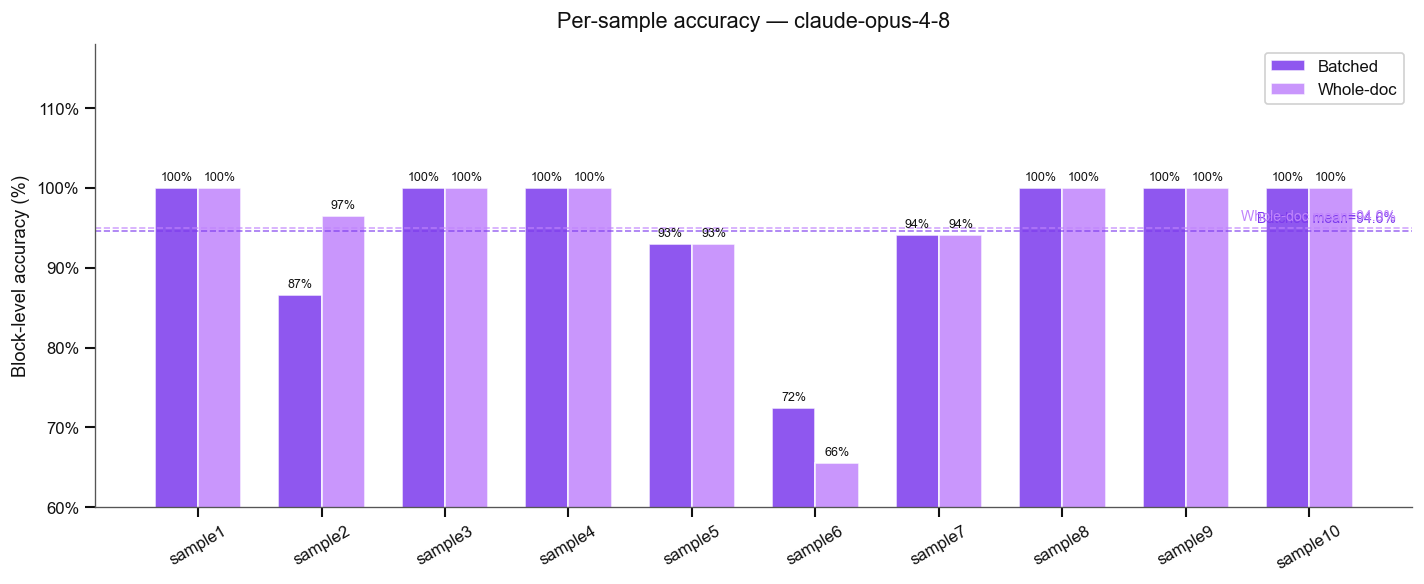

In [4]:
samples_ordered = df_b["sample"].tolist()
x = range(len(samples_ordered))

if WHOLEDOC_AVAILABLE:
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    acc_w = df_w.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    bars_b = ax.bar([xi - w/2 for xi in x], acc_b, width=w,
                    label="Batched", color=COLOR_BATCH, alpha=0.85, edgecolor="white")
    bars_w = ax.bar([xi + w/2 for xi in x], acc_w, width=w,
                    label="Whole-doc", color=COLOR_WHOLE, alpha=0.85, edgecolor="white")
    for bar, v in list(zip(bars_b, acc_b)) + list(zip(bars_w, acc_w)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.0f}%", ha="center", va="bottom", fontsize=7.5)
    avg_b, avg_w = acc_b.mean(), acc_w.mean()
    ax.axhline(avg_b, color=COLOR_BATCH, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.axhline(avg_w, color=COLOR_WHOLE, linestyle="--", linewidth=1.0, alpha=0.7)
    ax.text(len(x)-0.3, avg_b+0.6, f"Batched mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_BATCH)
    ax.text(len(x)-0.3, avg_w+0.6, f"Whole-doc mean={avg_w:.1f}%",
            ha="right", va="bottom", fontsize=8.5, color=COLOR_WHOLE)
    ax.legend(framealpha=0.9)
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    acc_b = df_b.set_index("sample").loc[samples_ordered, "accuracy"] * 100
    colors = [COLOR_BATCH if v >= 95 else "#f59e0b" if v >= 85 else "#dc2626" for v in acc_b]
    bars = ax.bar(samples_ordered, acc_b, color=colors, width=0.6, edgecolor="white")
    for bar, v in zip(bars, acc_b):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    avg_b = acc_b.mean()
    ax.axhline(avg_b, color="#444", linestyle="--", linewidth=1.0)
    ax.text(len(x)-0.45, avg_b+0.7, f"Mean={avg_b:.1f}%",
            ha="right", va="bottom", fontsize=9.5, color="#444")

ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(60, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME}", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Confusion matrix

Read **row by row**: each row = a true label, each column = what the model predicted.  
A perfect model has all mass on the diagonal.  
The most common failure mode is  being confused with  — both appear in the middle of a section and look like funder instructions.

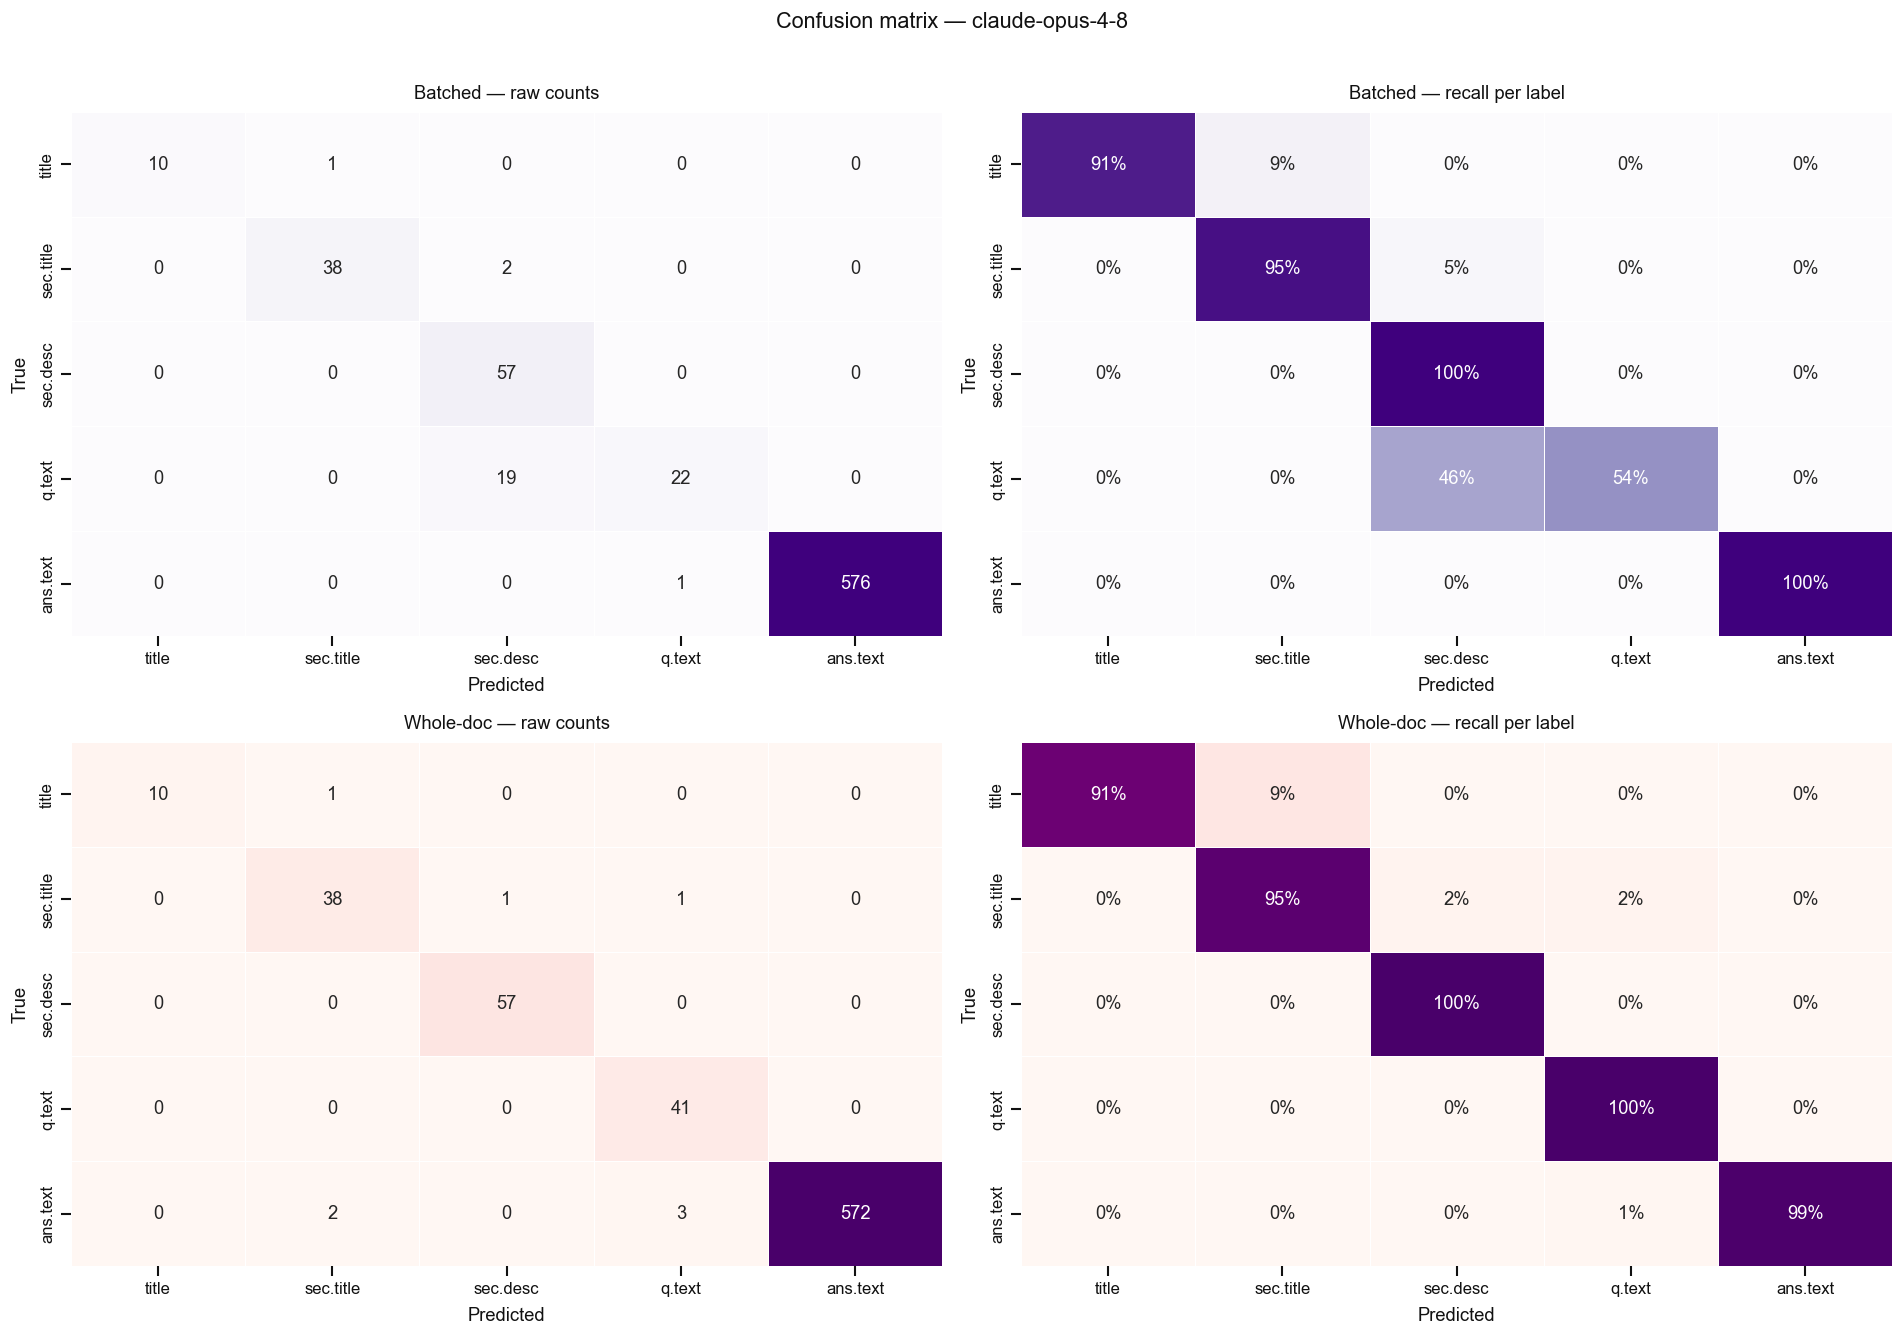

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_b, mat_bn = conf_to_df(conf_b)

if WHOLEDOC_AVAILABLE:
    mat_w, mat_wn = conf_to_df(conf_w)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    panels = [
        (axes[0,0], mat_b,  "d",   CMAP_BATCH, "Batched — raw counts"),
        (axes[0,1], mat_bn, ".0%", CMAP_BATCH, "Batched — recall per label"),
        (axes[1,0], mat_w,  "d",   CMAP_WHOLE, "Whole-doc — raw counts"),
        (axes[1,1], mat_wn, ".0%", CMAP_WHOLE, "Whole-doc — recall per label"),
    ]
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    panels = [
        (axes[0], mat_b,  "d",   CMAP_BATCH, "Raw counts"),
        (axes[1], mat_bn, ".0%", CMAP_BATCH, "Recall per label (row-normalised)"),
    ]

for ax, mat, fmt, cmap, title in panels:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
    ax.set_title(title, pad=8, fontsize=11)
    ax.set_xlabel("Predicted", labelpad=6)
    ax.set_ylabel("True", labelpad=6)

plt.suptitle(f"Confusion matrix — {MODEL_NAME}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 4 — Precision / Recall / F1 per label

F1 balances precision and recall. Values below 80% on a label indicate a reliability risk for the pipeline.  
The delta table at the bottom shows per-label gain from whole-doc context — this is the clearest signal for deciding which strategy to use in production.

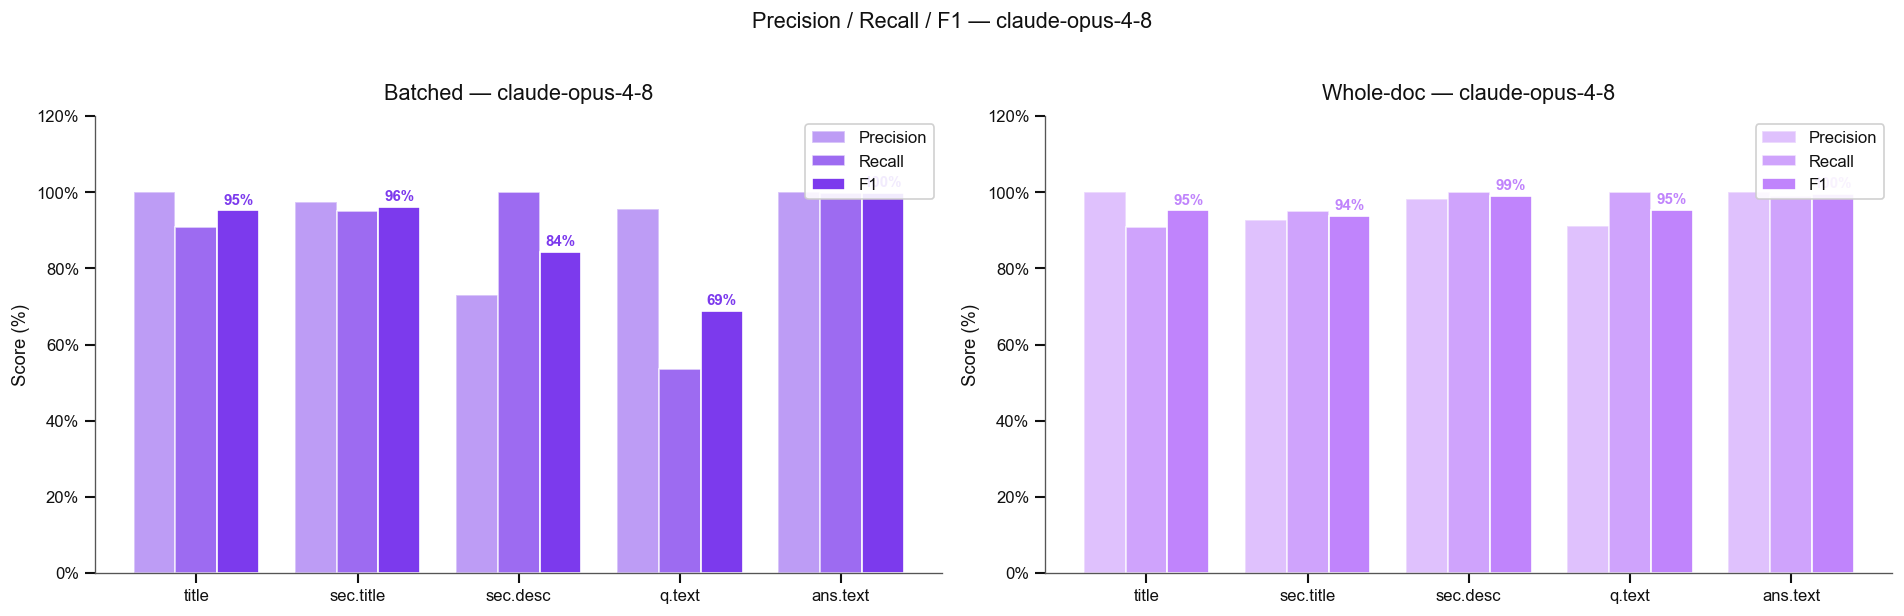

,f1_batch,f1_whole,delta
label,,,
title,95.2%,95.2%,0.0%
section.title,96.2%,93.8%,-2.4%
section.description,84.4%,99.1%,14.7%
question.text,68.8%,95.3%,26.6%
answer.text,99.9%,99.6%,-0.3%


In [6]:
def compute_f1_rows(conf):
    rows = []
    for lbl in LABELS:
        tp = conf.get(lbl, {}).get(lbl, 0)
        fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
        fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
        support = tp + fn
        p_ = tp / (tp + fp) if (tp + fp) else 0.
        r_ = tp / support   if support  else 0.
        f1 = 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.
        rows.append({"label": lbl, "precision": p_, "recall": r_, "f1": f1, "support": support})
    return pd.DataFrame(rows)

df_f1_b = compute_f1_rows(conf_b)

if WHOLEDOC_AVAILABLE:
    df_f1_w = compute_f1_rows(conf_w)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    panels = [(axes[0], df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}"),
              (axes[1], df_f1_w, COLOR_WHOLE, f"Whole-doc — {MODEL_NAME}")]
else:
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    panels = [(axes, df_f1_b, COLOR_BATCH, f"Batched — {MODEL_NAME}")]

for ax, df_f1, color, title in panels:
    xi, w = range(len(LABELS)), 0.26
    ax.bar([i - w for i in xi], df_f1["precision"]*100, width=w, label="Precision",
           color=color, alpha=0.5, edgecolor="white")
    ax.bar([i     for i in xi], df_f1["recall"]*100,    width=w, label="Recall",
           color=color, alpha=0.75, edgecolor="white")
    bars = ax.bar([i + w for i in xi], df_f1["f1"]*100, width=w, label="F1",
                  color=color, edgecolor="white")
    for bar, row in zip(bars, df_f1.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
    ax.set_ylim(0, 120); ax.set_ylabel("Score (%)")
    ax.set_title(title, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", framealpha=0.9)
    sns.despine(ax=ax)

plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

if WHOLEDOC_AVAILABLE:
    comb = df_f1_b.set_index("label")[["f1"]].rename(columns={"f1":"f1_batch"}).join(
           df_f1_w.set_index("label")[["f1"]].rename(columns={"f1":"f1_whole"}))
    comb["delta"] = comb["f1_whole"] - comb["f1_batch"]
    display(comb.style.format("{:.1%}").background_gradient(subset=["f1_batch","f1_whole"], cmap="Blues"))

## 5 — Mislabeled blocks

Use this table to distinguish **systematic** errors (same true→pred pair, many blocks) from **isolated** ones.  
Systematic patterns → prompt or strategy needs fixing. Isolated → acceptable noise.

In [7]:
def error_breakdown(df_err, label):
    print(f"  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors.\n"); return
    bd = (df_err.groupby(["true","pred"]).size()
          .reset_index(name="count").sort_values("count", ascending=False))
    print(bd.to_string(index=False)); print()

error_breakdown(errs_b, f"Batched — {MODEL_NAME}")
if WHOLEDOC_AVAILABLE:
    error_breakdown(errs_w, f"Whole-doc — {MODEL_NAME}")

  Batched — claude-opus-4-8: 26 mislabeled blocks
         true                pred  count
question.text section.description     19
     no_match         answer.text      3
section.title section.description      2
  answer.text       question.text      1
        title       section.title      1

  Whole-doc — claude-opus-4-8: 11 mislabeled blocks
         true                pred  count
  answer.text       question.text      3
     no_match       section.title      3
  answer.text       section.title      2
section.title       question.text      1
section.title section.description      1
        title       section.title      1



In [8]:
pd.set_option("display.max_colwidth", 100)
if not errs_b.empty:
    print("=== Batched errors ===")
    display(errs_b[["sample","page","true","pred","text"]])
if WHOLEDOC_AVAILABLE and not errs_w.empty:
    print("\n=== Whole-doc errors ===")
    display(errs_w[["sample","page","true","pred","text"]])

=== Batched errors ===


,sample,page,true,pred,text
0,sample2,2,question.text,section.description,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
2,sample2,2,question.text,section.description,and under what conditions;
3,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
4,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
5,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
6,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
7,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
8,sample2,2,question.text,section.description,cited;
9,sample2,2,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, expertise, etc.)"



=== Whole-doc errors ===


,sample,page,true,pred,text
0,sample2,1,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help from the"
1,sample2,2,section.title,question.text,preservation;
2,sample2,4,answer.text,question.text,Data Repositories. Senior investigators typically archive relevant data using their own group se...
3,sample2,4,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not prohibit their"
4,sample2,5,section.title,section.description,data.
5,sample6,1,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,no_match,section.title,2. Data and metadata standards. The PI’s research group will adopt the longstanding
7,sample6,1,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data and codes at
8,sample6,1,no_match,section.title,"4. Policies and provisions for re-use, re-distribution. Simulation data will in essence grow to"
9,sample6,1,no_match,section.title,5. Plans for archiving and preservation of access. Local data will be archived on the group’s
